# GLMsingle beta sanity check

Set the subject and task below, then run all cells. Two basic figures show category-average betas and pairwise beta differences on the subject's own T1w anatomy. This only reads completed results; it does not refit a model.

In [1]:
# User parameters
SUBJECT = "pp06"  # Can also use 6 or "06"
TASK = "audlocalizer"  # "audlocalizer" or "vislocalizer"
DISPLAY_THRESHOLD = 0.1  # Absolute beta (% BOLD); display only, not statistical
CUT_COORDS = None  # None uses five axial slices; optionally supply z coordinates

SPACE = "T1w"
RESULTS_DIR = "/gpfs/milgram/project/turk-browne/aa2842/auditory-objects-scenes-project/GLMsingle/results"
PREPROC_DIR = "/gpfs/milgram/scratch60/turk-browne/aa2842/sandbox/auditory-object-scenes-data/preprocessed"

In [2]:
import os
import nibabel as nib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from nilearn import plotting
from nilearn.image import new_img_like, resample_to_img
from nilearn.masking import unmask

%matplotlib inline

/gpfs/milgram/project/turk-browne/aa2842/conda_envs/myenv/lib/python3.7/site-packages/nilearn/__init__.py:67: FutureWarning: Python 3.7 support is deprecated and will be removed in release 0.12 of Nilearn. Consider switching to Python 3.9 or 3.10.
  _python_deprecation_warnings()


Betas are in [percent BOLD signal change](https://glmsingle.readthedocs.io/en/latest/wiki.html#what-are-the-units-of-the-single-trial-beta-weights-and-are-there-any-interpretation-issues). Visual uses the final Type B block betas; auditory uses the final Type D trial betas. Category means average all presentations, including auditory repetitions. The saved manifest links each beta to its category. To keep memory use low, load the masked GLMsingle arrays and restore only the three mean maps with the saved brain mask.

In [3]:
subject = str(SUBJECT).strip().replace("sub-", "").replace("pp", "")
sub_bids = f"sub-pp{subject.zfill(2)}"
task_settings = {"audlocalizer": ("auditory", "TypeD"), "vislocalizer": ("visual", "TypeB")}
prefix, model = task_settings[TASK]
task_dir = os.path.join(RESULTS_DIR, sub_bids, f"task-{TASK}")
stem = f"{sub_bids}_task-{TASK}_space-{SPACE}"

result_file = "TYPEB_FITHRF.npy" if TASK == "vislocalizer" else "TYPED_FITHRF_GLMDENOISE_RR.npy"
beta_path = os.path.join(task_dir, "glmsingle", result_file)
manifest_path = os.path.join(task_dir, f"{sub_bids}_task-{TASK}_desc-betaManifest.tsv")
mask_path = os.path.join(task_dir, f"{stem}_desc-GLMsingle_mask.nii.gz")
anat_path = os.path.join(PREPROC_DIR, sub_bids, "anat", f"{sub_bids}_desc-preproc_T1w.nii.gz")

beta_data = np.squeeze(np.load(beta_path, allow_pickle=True).item()["betasmd"])
n_betas = beta_data.shape[-1]
events = pd.read_csv(manifest_path, sep="\t").sort_values("beta_index")
assert np.array_equal(events["beta_index"].to_numpy(), np.arange(n_betas))
mask_img = nib.load(mask_path)
mask = mask_img.get_fdata() > 0
anat_img = resample_to_img(nib.load(anat_path), mask_img, interpolation="linear")

categories = {
    "Objects": f"{prefix}_object",
    "Scenes": f"{prefix}_scene",
    "Scrambled scenes": f"{prefix}_scrambled_scene",
}
mean_imgs = {}
counts = {}
for label, category in categories.items():
    indices = events.loc[events["category"] == category, "beta_index"].to_numpy(dtype=int)
    counts[label] = len(indices)
    mean_imgs[label] = unmask(beta_data[:, indices].mean(axis=1), mask_img)
del beta_data

cut_coords = CUT_COORDS
if cut_coords is None:
    cut_coords = plotting.find_cut_slices(mask_img, direction="z", n_cuts=5)
output_dir = os.path.join(task_dir, "qc_plots")
os.makedirs(output_dir, exist_ok=True)
print(f"{sub_bids} | {TASK} | GLMsingle {model}")
print(f"Loaded {n_betas} betas: {counts}")
print(f"Figures will be saved to: {output_dir}")

sub-pp06 | audlocalizer | GLMsingle TypeD
Loaded 320 betas: {'Objects': 106, 'Scenes': 107, 'Scrambled scenes': 107}
Figures will be saved to: /gpfs/milgram/project/turk-browne/aa2842/auditory-objects-scenes-project/GLMsingle/results/sub-pp06/task-audlocalizer/qc_plots


In [4]:
def plot_beta_maps(maps, title, filename):
    values = np.concatenate([img.get_fdata()[mask] for img in maps.values()])
    vmax = float(np.percentile(np.abs(values), 99))
    fig, axes = plt.subplots(3, 1, figsize=(13, 8))
    fig.subplots_adjust(top=0.91, bottom=0.08, hspace=0.25)
    for ax, (label, img) in zip(axes, maps.items()):
        plotting.plot_stat_map(
            img, bg_img=anat_img, axes=ax, figure=fig, title=label,
            display_mode="z", cut_coords=cut_coords, draw_cross=False,
            threshold=DISPLAY_THRESHOLD, cmap="RdBu_r",
            symmetric_cbar=True, vmax=vmax, colorbar=True, black_bg=False,
        )
    fig.suptitle(f"{sub_bids} | {TASK} | {model}: {title}", fontsize=14)
    fig.text(0.5, 0.025,
             f"Beta / beta difference (% BOLD); display cutoff = {DISPLAY_THRESHOLD}%; not significance-tested",
             ha="center", fontsize=10)
    fig.savefig(os.path.join(output_dir, filename), dpi=150, bbox_inches="tight")
    plt.show()

## 1. Category-average betas

Red means positive beta; blue means negative beta relative to the fitted baseline. All three rows use the same slices and colour range. The range is the pooled 99th percentile of absolute values inside the fitted brain mask, so extreme values saturate rather than setting the scale. No smoothing is applied. Only the anatomical background is resampled once to the beta grid for faster display.

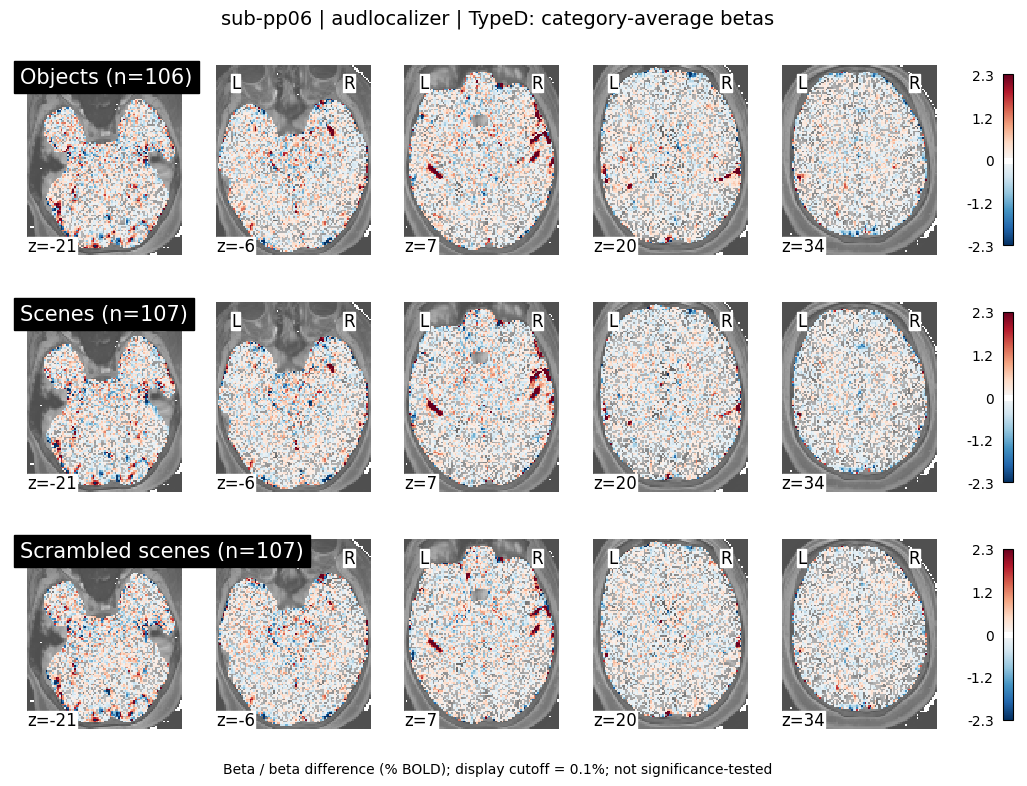

In [5]:
plot_beta_maps(
    {f"{label} (n={counts[label]})": img for label, img in mean_imgs.items()},
    "category-average betas",
    f"{sub_bids}_task-{TASK}_desc-categoryMean_betas.png",
)

## 2. Category differences

Red favours the first category in each subtraction; blue favours the second. These are differences of mean betas, **not** t/z maps or corrected contrasts. [The display cutoff](https://nilearn.github.io/stable/modules/generated/nilearn.plotting.plot_stat_map.html) only hides small absolute amplitudes. It is not a significance threshold.

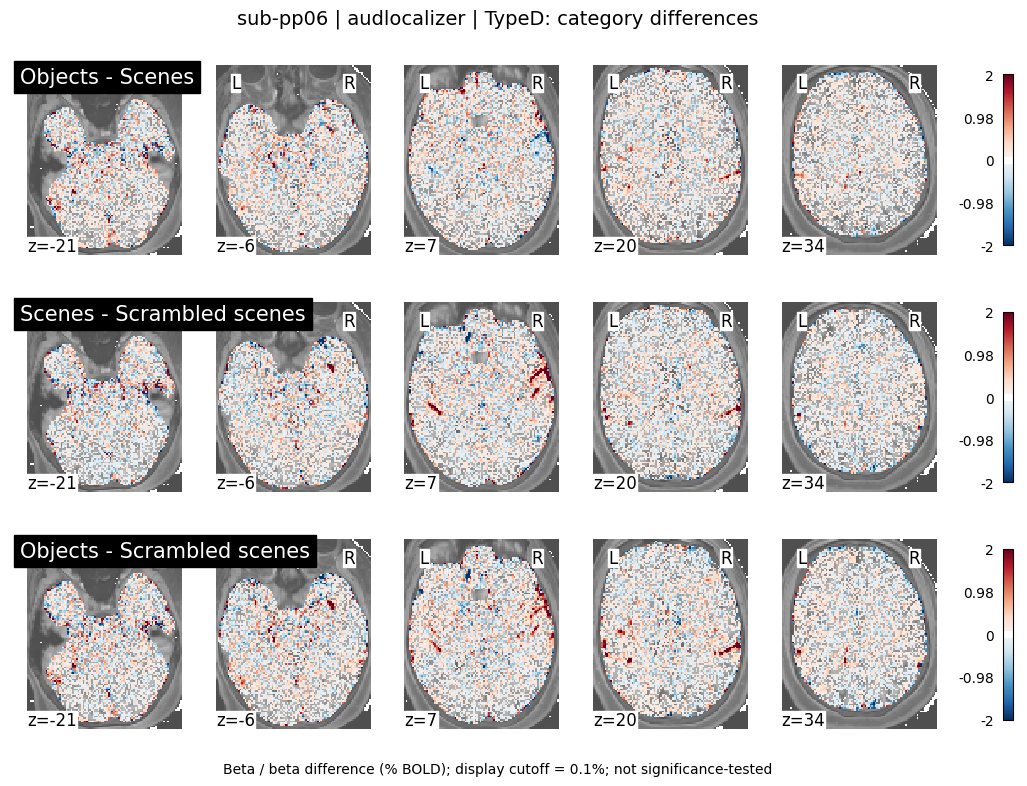

In [6]:
comparisons = [
    ("Objects", "Scenes"),
    ("Scenes", "Scrambled scenes"),
    ("Objects", "Scrambled scenes"),
]
difference_imgs = {
    f"{first} - {second}": new_img_like(
        mask_img, mean_imgs[first].get_fdata() - mean_imgs[second].get_fdata()
    )
    for first, second in comparisons
}
plot_beta_maps(
    difference_imgs, "category differences",
    f"{sub_bids}_task-{TASK}_desc-categoryDifference_betas.png",
)

These figures check that betas exist, have sensible spatial structure, and show where category differences occur. They do not establish category selectivity or statistical reliability. Avoid directly comparing visual and auditory amplitudes: their stimulus durations and final model types differ.